# 🎓 Desempenho Escolar no Brasil — Análise e Visualização de Dados**Avaliação G1 · Linguagem de Programação: Análise e Visualização de Dados com Python**## 1. Introdução ao problemaA educação é um dos principais indicadores de desenvolvimento de um país. Neste projeto analisamos como o**desempenho escolar** (média das notas, taxas de aprovação e reprovação) varia entre **regiões**, **redes de ensino**,**disciplinas** e **anos** (2015–2024), e se **renda familiar** e **acesso à internet** estão associados a esse desempenho.**Perguntas norteadoras**1. Qual o desempenho médio geral e como ele se distribui?2. Existem diferenças entre regiões, redes (pública × privada) e disciplinas?3. Como o desempenho evoluiu no tempo? Houve efeito visível da pandemia (2020–2021)?4. Renda e acesso à internet se correlacionam com as notas?5. A base é confiável? Que inconsistências precisam ser tratadas?

## 2. Explicação da base de dadosArquivo `dados/simulacao_desempenho_escolar_brasil.csv` — **740 registros** semestrais (2015–2024) de **37 municípios**em **20 UFs**, 5 regiões, 2 redes de ensino e 5 disciplinas. ⚠️ Trata-se de uma **base simulada**.| Coluna | Descrição ||---|---|| `ano`, `semestre`, `data` | Período da observação || `regiao`, `uf`, `municipio` | Localização || `rede_ensino` | Pública ou Privada || `disciplina` | Matemática, Português, Ciências, História ou Geografia || `media_notas` | Média das notas (0–100) || `taxa_aprovacao`, `taxa_reprovacao` | Percentuais (%) || `acesso_internet` | % de acesso à internet || `renda_media_familiar` | Renda média familiar (R$) || `indice_desempenho` | Índice sintético de desempenho || `nivel_desempenho` | Classificação original: Baixo, Médio, Alto, Excelente |

## 3. Leitura dos dados

In [1]:
import syssys.path.append("..")          # permite importar o utils.py da raiz do projetoimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsfrom utils import tratar_dados, ORDEM_NIVELsns.set_theme(style="whitegrid", palette="viridis")df_raw = pd.read_csv("../dados/simulacao_desempenho_escolar_brasil.csv")print("Dimensões:", df_raw.shape)df_raw.head()

Dimensões: (740, 15)


,ano,semestre,data,regiao,uf,municipio,rede_ensino,disciplina,media_notas,taxa_aprovacao,taxa_reprovacao,acesso_internet,renda_media_familiar,indice_desempenho,nivel_desempenho
0,2015,1,2015-06-01,Norte,AM,Manaus,Pública,Matemática,38.05,81.01,17.27,82.1,4624.09,66.56,Excelente
1,2015,1,2015-06-01,Norte,PA,Belém,Privada,Geografia,61.51,87.30,1.13,92.3,3178.52,51.25,Baixo
2,2015,1,2015-06-01,Norte,PA,Santarém,Privada,Português,62.11,89.05,12.48,74.9,4316.80,52.29,Baixo
3,2015,1,2015-06-01,Norte,RO,Porto Velho,Pública,História,65.67,98.89,15.36,62.2,1792.32,42.05,Alto
4,2015,1,2015-06-01,Norte,TO,Palmas,Pública,Português,54.86,95.94,23.97,60.0,1629.89,86.67,Baixo


In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   740 non-null    int64  
 1   semestre              740 non-null    int64  
 2   data                  740 non-null    str    
 3   regiao                740 non-null    str    
 4   uf                    740 non-null    str    
 5   municipio             740 non-null    str    
 6   rede_ensino           740 non-null    str    
 7   disciplina            740 non-null    str    
 8   media_notas           740 non-null    float64
 9   taxa_aprovacao        740 non-null    float64
 10  taxa_reprovacao       740 non-null    float64
 11  acesso_internet       740 non-null    float64
 12  renda_media_familiar  740 non-null    float64
 13  indice_desempenho     740 non-null    float64
 14  nivel_desempenho      740 non-null    str    
dtypes: float64(6), int64(2), str(7)
me

## 4. Limpeza e preparação

In [3]:
print("Valores nulos por coluna:"); print(df_raw.isna().sum().sum(), "nulos no total")print("Linhas duplicadas:", df_raw.duplicated().sum())print("Categorias:", {c: df_raw[c].nunique() for c in ["regiao", "uf", "municipio", "rede_ensino", "disciplina", "nivel_desempenho"]})df_raw.describe().round(2)

Valores nulos por coluna:
0 nulos no total
Linhas duplicadas: 0
Categorias: {'regiao': 5, 'uf': 20, 'municipio': 37, 'rede_ensino': 2, 'disciplina': 5, 'nivel_desempenho': 4}


,ano,semestre,media_notas,taxa_aprovacao,taxa_reprovacao,acesso_internet,renda_media_familiar,indice_desempenho
count,740.00,740.0,740.00,740.00,740.00,740.00,740.00,740.00
mean,2019.50,1.5,64.97,77.42,18.36,67.41,3742.12,64.86
std,2.87,0.5,17.53,12.80,9.62,18.55,1288.07,17.01
min,2015.00,1.0,35.08,55.03,1.11,35.00,1500.71,35.01
25%,2017.00,1.0,49.68,66.48,10.36,51.28,2626.78,50.61
50%,2019.50,1.5,65.16,77.21,18.56,67.40,3764.12,63.75
75%,2022.00,2.0,80.62,88.88,26.86,83.60,4811.78,80.58
max,2024.00,2.0,94.93,98.93,35.00,98.00,5987.62,95.00


### Verificações de consistênciaA base não tem nulos nem duplicatas, mas duas regras de negócio precisam ser testadas:1. **Aprovação + reprovação não pode ultrapassar 100%.**2. **O `nivel_desempenho` deveria acompanhar o `indice_desempenho`.**

In [4]:
soma = df_raw["taxa_aprovacao"] + df_raw["taxa_reprovacao"]print(f"Registros com aprovação + reprovação > 100%: {(soma > 100).sum()} ({(soma > 100).mean():.1%})")print("\nÍndice de desempenho por nível original (deveria crescer de Baixo a Excelente):")print(df_raw.groupby("nivel_desempenho")["indice_desempenho"].mean().reindex(ORDEM_NIVEL).round(2))

Registros com aprovação + reprovação > 100%: 291 (39.3%)

Índice de desempenho por nível original (deveria crescer de Baixo a Excelente):
nivel_desempenho
Baixo        64.55
Médio        65.49
Alto         65.23
Excelente    64.28
Name: indice_desempenho, dtype: float64


**Decisão de tratamento:** não removemos esses registros (perderíamos ~39% da base). Em vez disso, criamos a coluna`taxas_inconsistentes` para sinalizá-los — o dashboard oferece um filtro para excluí-los. Como o nível original **não** segueo índice (médias praticamente idênticas nos quatro níveis), criamos também `nivel_calculado`, baseado em quartis do índice.

## 5. Engenharia de atributos

In [5]:
df = tratar_dados(df_raw)   # mesma função usada no banco de dados e no dashboardnovas = ["periodo", "taxa_total", "taxas_inconsistentes", "situacao_notas", "periodo_pandemia",         "faixa_renda", "faixa_internet", "nivel_calculado", "lat", "lon"]print("Novas colunas:", novas)df[["municipio", "periodo", "taxa_total", "taxas_inconsistentes", "faixa_renda", "faixa_internet", "nivel_calculado"]].head()

Novas colunas: ['periodo', 'taxa_total', 'taxas_inconsistentes', 'situacao_notas', 'periodo_pandemia', 'faixa_renda', 'faixa_internet', 'nivel_calculado', 'lat', 'lon']


,municipio,periodo,taxa_total,taxas_inconsistentes,faixa_renda,faixa_internet,nivel_calculado
0,Manaus,2015-S1,98.28,False,Alta,Alto (>75%),Alto
1,Belém,2015-S1,88.43,False,Média,Alto (>75%),Médio
2,Santarém,2015-S1,101.53,True,Média,Médio (50–75%),Médio
3,Porto Velho,2015-S1,114.25,True,Baixa,Médio (50–75%),Baixo
4,Palmas,2015-S1,119.91,True,Baixa,Médio (50–75%),Excelente


| Atributo | Como foi criado ||---|---|| `periodo` | `ano` + `-S` + `semestre` (ex.: 2018-S2) || `taxa_total` / `taxas_inconsistentes` | soma aprovação + reprovação e flag `> 100` || `situacao_notas` | média ≥ 60 ou < 60 || `periodo_pandemia` | `True` para 2020–2021 || `faixa_renda` | tercis da renda (Baixa, Média, Alta) || `faixa_internet` | cortes <50%, 50–75%, >75% || `nivel_calculado` | quartis do índice de desempenho || `lat`, `lon` | coordenadas do município (para o mapa) |

## 6. Análise exploratória

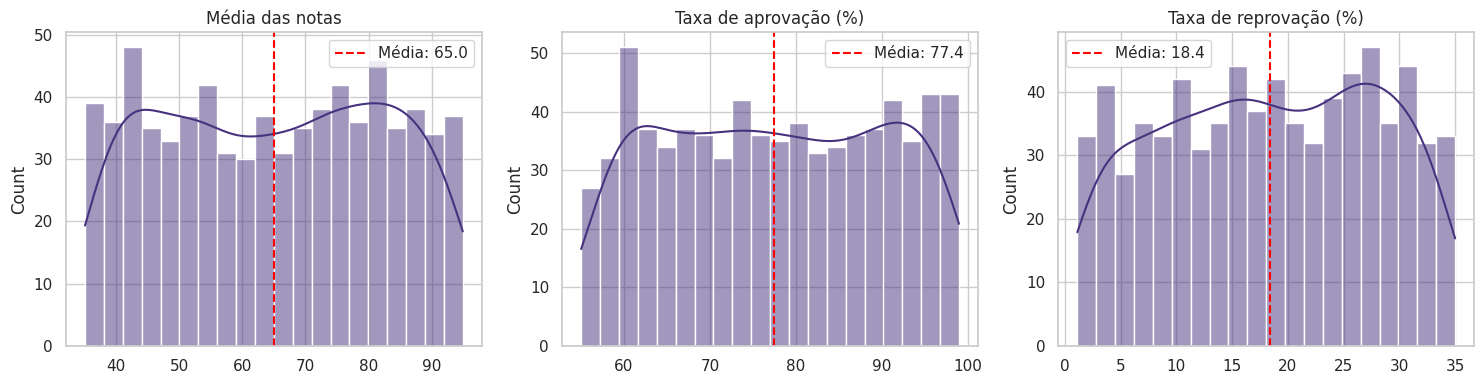

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))for ax, col, titulo in zip(axes, ["media_notas", "taxa_aprovacao", "taxa_reprovacao"],                           ["Média das notas", "Taxa de aprovação (%)", "Taxa de reprovação (%)"]):    sns.histplot(df[col], bins=20, kde=True, ax=ax)    ax.axvline(df[col].mean(), color="red", ls="--", label=f"Média: {df[col].mean():.1f}")    ax.set_title(titulo); ax.set_xlabel(""); ax.legend()plt.tight_layout()plt.savefig("../imagens/01_distribuicoes.png", dpi=130, bbox_inches="tight")plt.show()

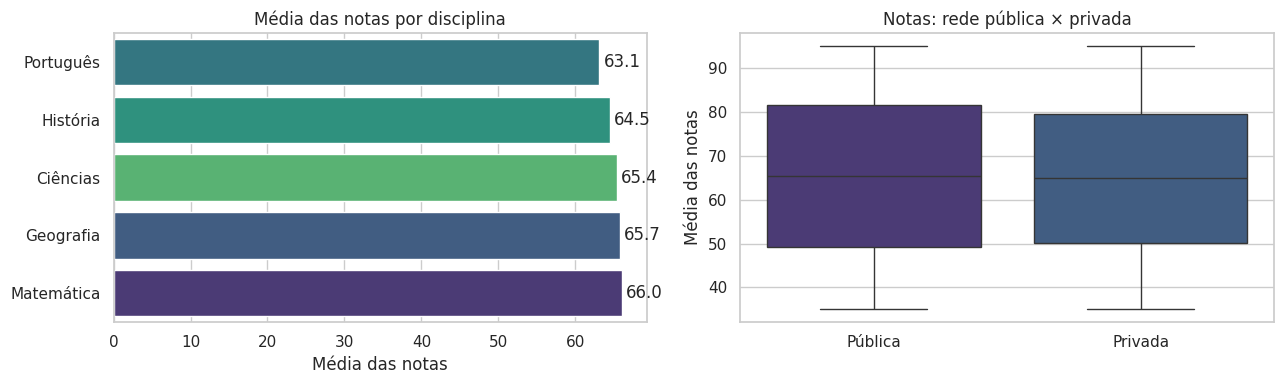

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))ordem = df.groupby("disciplina")["media_notas"].mean().sort_values().indexsns.barplot(data=df, x="media_notas", y="disciplina", order=ordem, hue="disciplina", legend=False,            errorbar=None, ax=axes[0])for c in axes[0].containers: axes[0].bar_label(c, fmt="%.1f", padding=3)axes[0].set_title("Média das notas por disciplina"); axes[0].set_xlabel("Média das notas"); axes[0].set_ylabel("")sns.boxplot(data=df, x="rede_ensino", y="media_notas", hue="rede_ensino", legend=False, ax=axes[1])axes[1].set_title("Notas: rede pública × privada"); axes[1].set_xlabel(""); axes[1].set_ylabel("Média das notas")plt.tight_layout()plt.savefig("../imagens/02_disciplina_rede.png", dpi=130, bbox_inches="tight")plt.show()

In [8]:
print(df.groupby("rede_ensino")[["media_notas", "taxa_aprovacao", "taxa_reprovacao"]].mean().round(2))t, p = stats.ttest_ind(df[df.rede_ensino == "Privada"]["media_notas"],                       df[df.rede_ensino == "Pública"]["media_notas"])print(f"\nTeste t (privada × pública, média das notas): t = {t:.3f}, p-valor = {p:.3f}")

             media_notas  taxa_aprovacao  taxa_reprovacao
rede_ensino                                              
Privada            64.89           77.71            17.69
Pública            65.05           77.14            19.02

Teste t (privada × pública, média das notas): t = -0.120, p-valor = 0.904


## 7. KPIs

In [9]:
kpis = {    "Registros analisados": len(df),    "Média das notas": round(df["media_notas"].mean(), 2),    "Taxa média de aprovação (%)": round(df["taxa_aprovacao"].mean(), 2),    "Taxa média de reprovação (%)": round(df["taxa_reprovacao"].mean(), 2),    "Índice médio de desempenho": round(df["indice_desempenho"].mean(), 2),    "Acesso médio à internet (%)": round(df["acesso_internet"].mean(), 2),    "Renda média familiar (R$)": round(df["renda_media_familiar"].mean(), 2),    "% de registros com nota ≥ 60": round((df["media_notas"] >= 60).mean() * 100, 1),    "% de registros com taxas inconsistentes": round(df["taxas_inconsistentes"].mean() * 100, 1),}pd.Series(kpis, name="Valor").to_frame()

,Valor
Registros analisados,740.00
Média das notas,64.97
Taxa média de aprovação (%),77.42
Taxa média de reprovação (%),18.36
Índice médio de desempenho,64.86
Acesso médio à internet (%),67.41
Renda média familiar (R$),3742.12
% de registros com nota ≥ 60,58.40
% de registros com taxas inconsistentes,39.30


## 8. Gráficos

### 8.1 Evolução temporal (média anual e média móvel semestral)

ano           2015   2016   2017   2018   2019   2020   2021   2022   2023   2024
media_notas  65.48  62.53  66.46  62.40  66.52  64.75  65.17  62.51  67.90  66.01
variacao_%     NaN  -4.51   6.30  -6.12   6.60  -2.66   0.66  -4.08   8.62  -2.78

Pandemia (2020-21) vs demais anos:
periodo_pandemia
Demais anos    64.98
Pandemia       64.96
Name: media_notas, dtype: float64


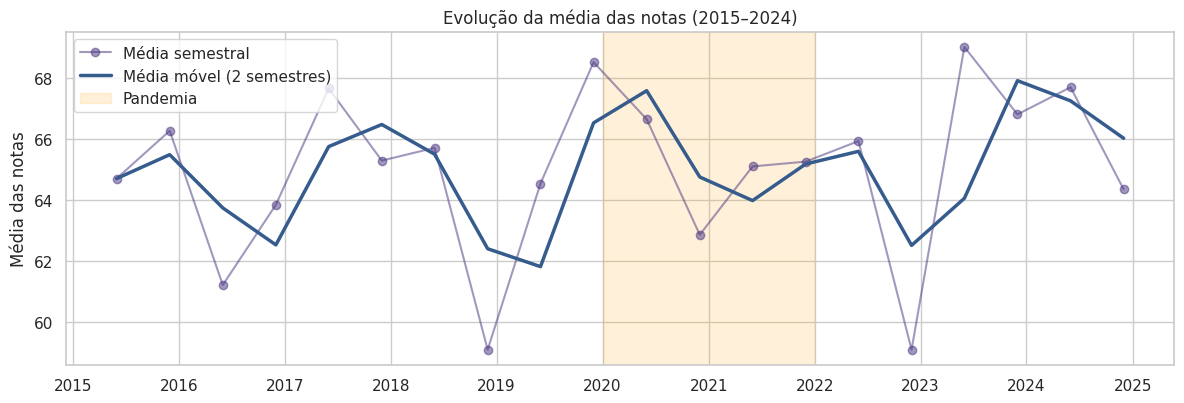

In [10]:
sem = df.groupby("data", as_index=False)["media_notas"].mean().sort_values("data")sem["media_movel"] = sem["media_notas"].rolling(2, min_periods=1).mean()fig, ax = plt.subplots(figsize=(12, 4.2))ax.plot(sem["data"], sem["media_notas"], marker="o", alpha=0.5, label="Média semestral")ax.plot(sem["data"], sem["media_movel"], lw=2.5, label="Média móvel (2 semestres)")ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="orange", alpha=0.15, label="Pandemia")ax.set_title("Evolução da média das notas (2015–2024)"); ax.set_ylabel("Média das notas"); ax.legend()plt.tight_layout()plt.savefig("../imagens/03_evolucao_temporal.png", dpi=130, bbox_inches="tight")plt.show()anual = df.groupby("ano")["media_notas"].mean().to_frame("media_notas")anual["variacao_%"] = anual["media_notas"].pct_change() * 100print(anual.round(2).T.to_string())print("\nPandemia (2020-21) vs demais anos:")print(df.groupby("periodo_pandemia")["media_notas"].mean().round(2).rename({False: "Demais anos", True: "Pandemia"}))

### 8.2 Comparação entre regiões

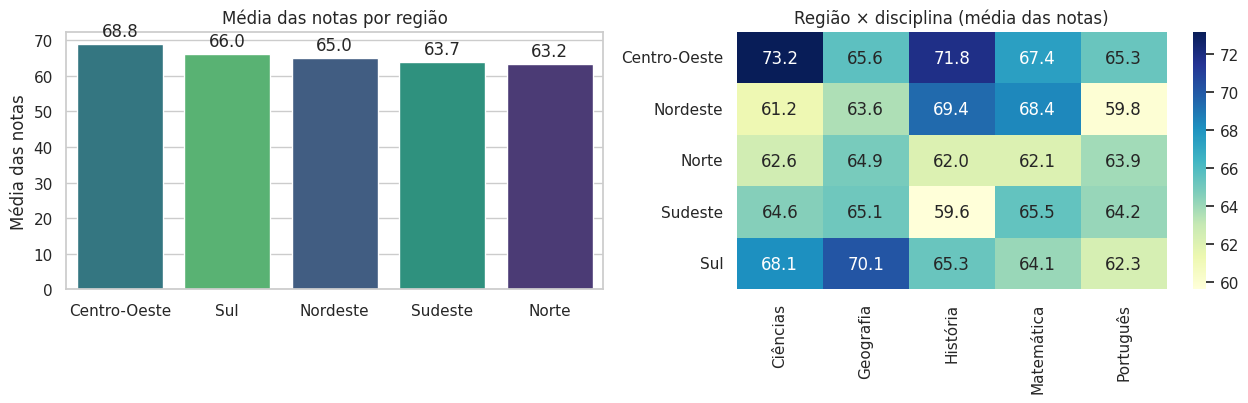

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))ordem_reg = df.groupby("regiao")["media_notas"].mean().sort_values(ascending=False).indexsns.barplot(data=df, x="regiao", y="media_notas", order=ordem_reg, hue="regiao", legend=False, errorbar=None, ax=axes[0])for c in axes[0].containers: axes[0].bar_label(c, fmt="%.1f", padding=3)axes[0].set_title("Média das notas por região"); axes[0].set_xlabel(""); axes[0].set_ylabel("Média das notas")heat = df.pivot_table(index="regiao", columns="disciplina", values="media_notas", aggfunc="mean")sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])axes[1].set_title("Região × disciplina (média das notas)"); axes[1].set_xlabel(""); axes[1].set_ylabel("")plt.tight_layout()plt.savefig("../imagens/04_regioes.png", dpi=130, bbox_inches="tight")plt.show()

### 8.3 Correlação estatística

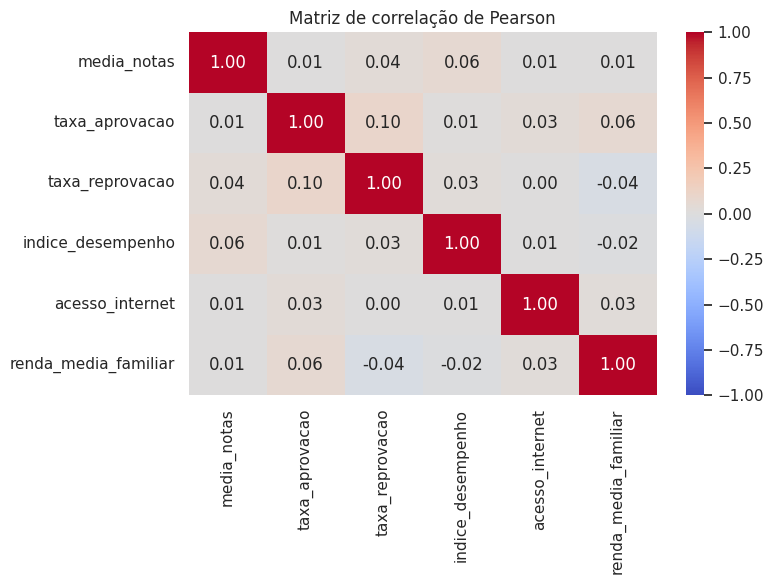

,X,Y,r,p-valor,"significativa (p<0,05)"
0,renda_media_familiar,media_notas,0.007,0.850,False
1,acesso_internet,media_notas,0.006,0.881,False
2,renda_media_familiar,taxa_aprovacao,0.063,0.089,False
3,acesso_internet,taxa_aprovacao,0.033,0.368,False


In [12]:
cols = ["media_notas", "taxa_aprovacao", "taxa_reprovacao", "indice_desempenho", "acesso_internet", "renda_media_familiar"]fig, ax = plt.subplots(figsize=(8, 6))sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax)ax.set_title("Matriz de correlação de Pearson")plt.tight_layout()plt.savefig("../imagens/05_correlacao.png", dpi=130, bbox_inches="tight")plt.show()linhas = []for x, y in [("renda_media_familiar", "media_notas"), ("acesso_internet", "media_notas"),             ("renda_media_familiar", "taxa_aprovacao"), ("acesso_internet", "taxa_aprovacao")]:    r, p = stats.pearsonr(df[x], df[y])    linhas.append({"X": x, "Y": y, "r": round(r, 3), "p-valor": round(p, 3), "significativa (p<0,05)": p < 0.05})pd.DataFrame(linhas)

faixa_renda
Baixa    64.99
Média    64.36
Alta     65.56
Name: media_notas, dtype: float64
faixa_internet
Baixo (<50%)      65.05
Médio (50–75%)    65.01
Alto (>75%)       64.89
Name: media_notas, dtype: float64


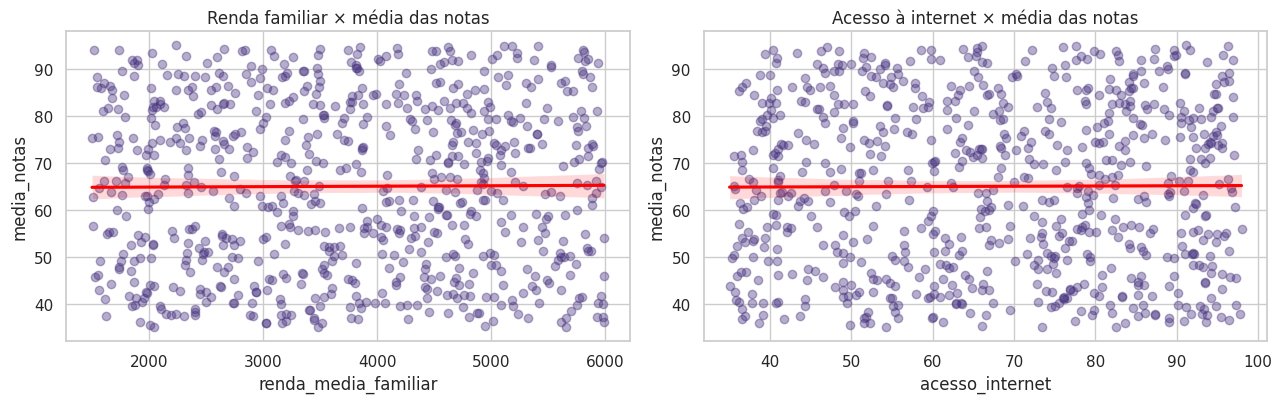

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))sns.regplot(data=df, x="renda_media_familiar", y="media_notas", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"}, ax=axes[0])axes[0].set_title("Renda familiar × média das notas")sns.regplot(data=df, x="acesso_internet", y="media_notas", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"}, ax=axes[1])axes[1].set_title("Acesso à internet × média das notas")plt.tight_layout()plt.savefig("../imagens/06_renda_internet.png", dpi=130, bbox_inches="tight")plt.show()print(df.groupby("faixa_renda", observed=True)["media_notas"].mean().round(2))print(df.groupby("faixa_internet", observed=True)["media_notas"].mean().round(2))

### 8.4 Qualidade dos dados

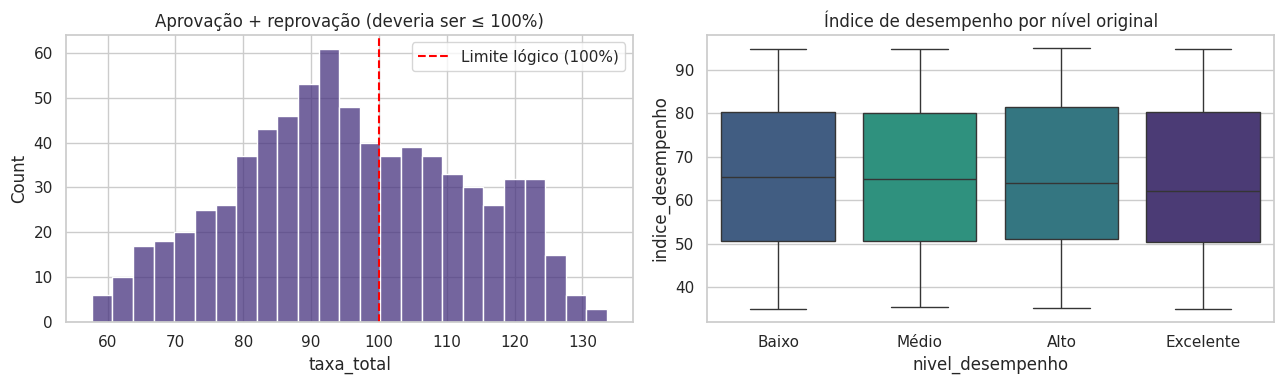

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))sns.histplot(df["taxa_total"], bins=25, ax=axes[0])axes[0].axvline(100, color="red", ls="--", label="Limite lógico (100%)")axes[0].set_title("Aprovação + reprovação (deveria ser ≤ 100%)"); axes[0].legend()sns.boxplot(data=df, x="nivel_desempenho", y="indice_desempenho", order=ORDEM_NIVEL, hue="nivel_desempenho", legend=False, ax=axes[1])axes[1].set_title("Índice de desempenho por nível original")plt.tight_layout()plt.savefig("../imagens/07_qualidade_dados.png", dpi=130, bbox_inches="tight")plt.show()

## 9. Interpretação dos resultados- **Visão geral:** a média das notas é **65,0** (desvio-padrão ≈ 17,5), com **77,4% de aprovação** e **18,4% de reprovação**.  As notas se distribuem de forma bem espalhada entre 35 e 95, sem concentração em torno da média.- **Disciplinas:** Matemática (66,0) e Geografia (65,8) lideram; Português tem a menor média (63,1). A diferença total é de apenas ~3 pontos.- **Rede de ensino:** pública (65,0) e privada (64,9) são praticamente idênticas — o teste t não encontra diferença significativa (p ≈ 0,90).- **Regiões:** Centro-Oeste tem a maior média (68,8) e Norte a menor (63,2) — cerca de 5,7 pontos de distância. Com poucos municípios por região, essa diferença deve ser lida com cautela.- **Tempo:** a série oscila entre 62,4 (2018) e 67,9 (2023), alternando altas e quedas, **sem tendência definida**. Durante a pandemia a média foi 65,0, idêntica à dos demais anos — não há efeito visível.- **Correlações:** renda × notas (r ≈ 0,01) e internet × notas (r ≈ 0,01) são **desprezíveis e não significativas**. As notas médias por faixa de renda e de internet são quase iguais.- **Qualidade dos dados:** 291 registros (39,3%) têm aprovação + reprovação > 100%, e o nível de desempenho original não segue o índice. Esses sinais são típicos de dados gerados aleatoriamente.

## 10. ConclusãoO projeto percorreu todo o ciclo de análise: leitura, limpeza, engenharia de atributos, exploração, KPIs, visualizações e dashboard interativo.**Principais achados:** o desempenho médio é de 65 pontos, com diferenças pequenas entre disciplinas, redes e regiões, e **nenhuma relação estatística relevante** entre renda, acesso à internet e notas. A evolução temporal não mostra tendência nem impacto da pandemia.**Limitações e cuidados:** a base é **simulada** — os padrões (ou a falta deles) refletem a aleatoriedade da geração dos dados, e **não** a realidade educacional brasileira. Em dados reais (como INEP/IDEB/SAEB), esperaríamos associação positiva entre renda, conectividade e desempenho, e diferenças maiores entre redes e regiões.**Próximos passos:** repetir a análise com dados reais, incluir variáveis socioeconômicas adicionais e testar modelos preditivos (regressão) para o desempenho.